# HVAC vs HVDC Systems

Technology decisions have an impact on a wind project's CapEx. This example will provide a basic
setup to compare how different project sizes, export cable types (HVDC or HVDC), distances to shore,
and etc. effect project costs. Instead of other guides' approach of using the `ExportSystemDesign`,
this will highlight the use of the `ElectricalDesign` model that co-designs the substation
and export cabling system.

In [1]:
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ORBIT.phases.design import ElectricalDesign
from ORBIT import ProjectManager, ParametricManager

# Apply thousands separators and no decimals to floats
pd.options.display.float_format = '{:,.0f}'.format

## Setup The Models

Here we will setup a base configuration for use with `ProjectManager` plus additional configurations
for running in the `ParametericManager` to look at the cost tradeoffs in export cable types
depending on project size.
Config must include all required variables except those you plan to vary. In this example, we will be manually vary the cable type and then use the `ParametricManager` to vary cable type and plant capacity.

In [2]:
base_config = {
    "export_cable_install_vessel": "example_cable_lay_vessel",
    "site": {
        "distance": 100,
        "depth": 20,
        "distance_to_landfall": 50,
    },
    "plant": {
        "capacity": 1000,
    },
    "turbine": "12MW_generic",
    "oss_install_vessel": "example_heavy_lift_vessel",
    "feeder": "future_feeder",
    "design_phases": [
        "ElectricalDesign",
    ],
    "install_phases": [
        "ExportCableInstallation",
        "OffshoreSubstationInstallation",
    ],
}

Now we can create an HVAC and HVDC variation of the `base_config`

In [3]:
hvac_config = deepcopy(base_config)
hvac_config["export_system_design"] = {"cables": "XLPE_1000mm_220kV"}

hvdc_config = deepcopy(base_config)
hvdc_config["export_system_design"] = {"cables": "HVDC_2000mm_320kV"}


hvac_project = ProjectManager(hvac_config)
hvac_project.run()

hvdc_project = ProjectManager(hvdc_config)
hvdc_project.run()

ORBIT library intialized at '/Users/rhammond/GitHub_Public/ORBIT/library'
OffshoreSubstationInstallation:
OffshoreSubstationInstallation:


## Compare the Results

In [4]:
print(f"HVAC CapEx per kW: ${hvac_project.total_capex_per_kw:,.2f} ")
print(f"HVDC CapEx per kW: ${hvdc_project.total_capex_per_kw:,.2f} ")

HVAC CapEx per kW: $2,974.90 
HVDC CapEx per kW: $3,377.08


In [5]:
capex_df = (
    pd.DataFrame(
        [*hvac_project.capex_breakdown.items()],
        columns=["Category", "HVAC CapEx"]
    ).set_index("Category")
    .join(
        pd.DataFrame(
            [*hvdc_project.capex_breakdown.items()],
            columns=["Category", "HVDC CapEx"]
        ).set_index("Category")
    )
)
capex_df

,HVAC CapEx,HVDC CapEx
Category,,
Export System,"318,311,296","95,436,000"
Offshore Substation,"245,496,817","795,031,033"
Export System Installation,"49,953,788","14,008,968"
Offshore Substation Installation,"3,861,208","3,861,208"
Onshore Substation,"195,273,630","254,763,736"
Turbine,"1,310,400,000","1,310,400,000"
Soft,"496,606,631","548,577,239"
Project,"355,000,000","355,000,000"


## Setup The Parametric Runs

From the two base cases above, we see that HVDC cables are more cost effective than HVAC by
roughly 30%. However, the offshore substation (OSS) is over three times the cost of an HVAC OSS.
To compare this sensitivity and see if there is an point that these technologies cross we'll use
the `ParametricManager` and sweep each cable for a range of plant capacities.

In [6]:
parameters = {
    "export_system_design.cables": ["XLPE_1000mm_220kV", "HVDC_2000mm_320kV"],
    "plant.capacity": np.arange(100, 2100, 100),
}

results = {
    "cable_cost": lambda run: run.total_cable_cost,
    "oss_cost": lambda run: run.substation_cost,
    "num_cables": lambda run: run.num_cables,
    "num_substations": lambda run: run.num_substations,
}

In [7]:
parametric = ParametricManager(
    base_config, parameters, results, module = ElectricalDesign, product=True
)
parametric.run()

## Compare the Cost vs Capacity Trade Off

The inflection point of the below graph shows that for a project that has less than 700 MW of
capacity, HVAC is more cost effective, and for projects greater than 700 MW should, HVDC is more
cost effective.

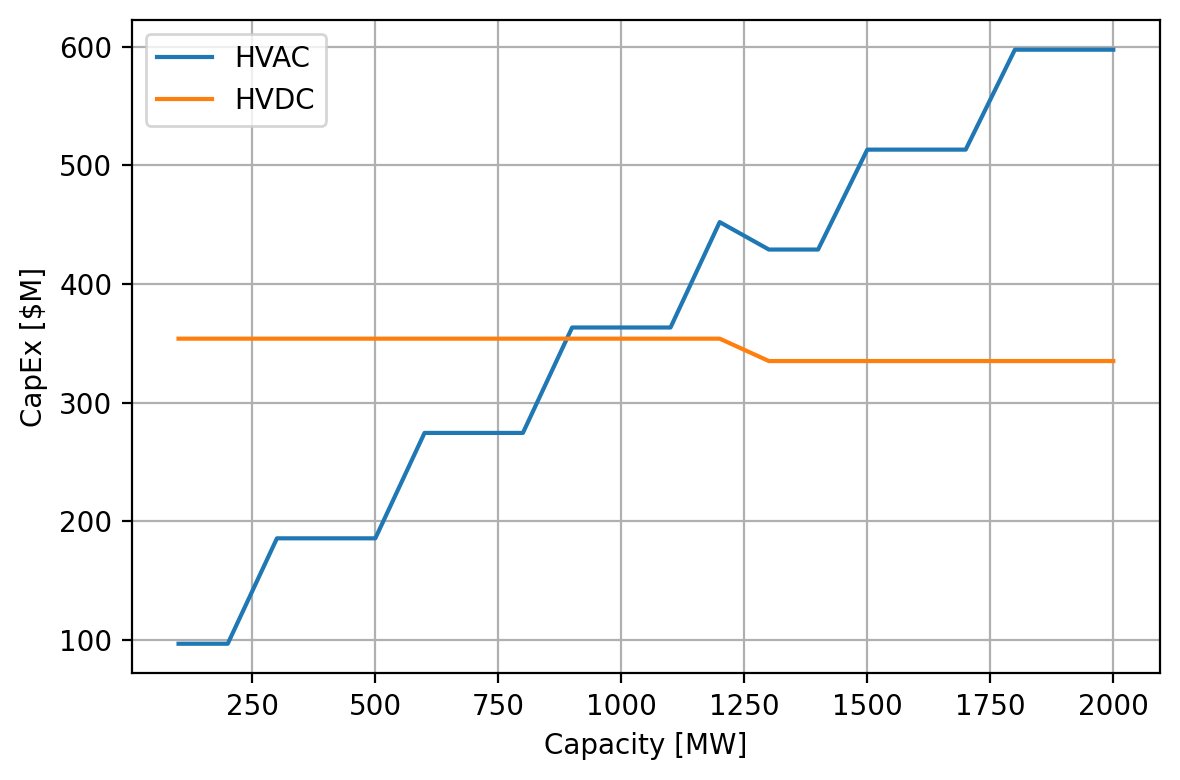

In [8]:
df = pd.DataFrame(parametric.results)

fig = plt.figure(figsize=(6,4), dpi=200)
ax = fig.subplots(1)

hvac_df = df[df["export_system_design.cables.XLPE_1000mm_220kV.name"] == "XLPE_1000mm_220kV"]
hvdc_df = df[df["export_system_design.cables.HVDC_2000mm_320kV.name"] == "HVDC_2000mm_320kV"]

ax.plot(
    hvac_df["plant.capacity"],
    (hvac_df["cable_cost"] + hvac_df["oss_cost"]) / 1e6,
    label="HVAC"
)

ax.plot(
    hvdc_df["plant.capacity"],
    (hvdc_df["cable_cost"] + hvdc_df["oss_cost"]) / 1e6,
    label="HVDC",
)

ax.set_ylabel("CapEx [$M]")
ax.set_xlabel("Capacity [MW]")
ax.legend()
ax.grid()

fig.tight_layout()